TIF files found:
  Position01Channel01Frames000001.tif
  Position01Channel01Frames000002.tif
  Position01Channel01Frames000003.tif
  Position01Channel01Frames000004.tif
  Position01Channel01Frames000005.tif

labelsstack shape: (10, 256, 32)
labelsstack_resized shape: (10, 211, 22)
Cells in frame 0: 5
Raw image shape: (520, 696)


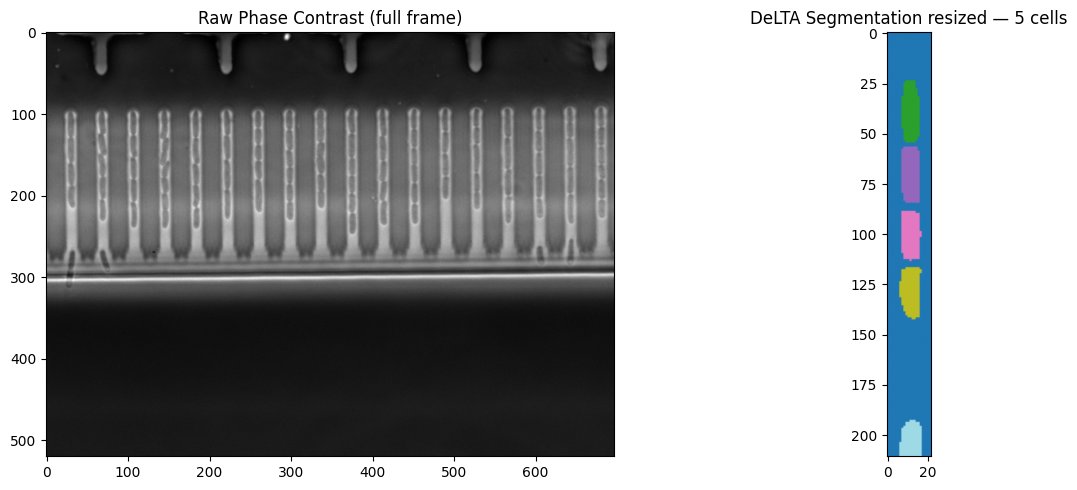

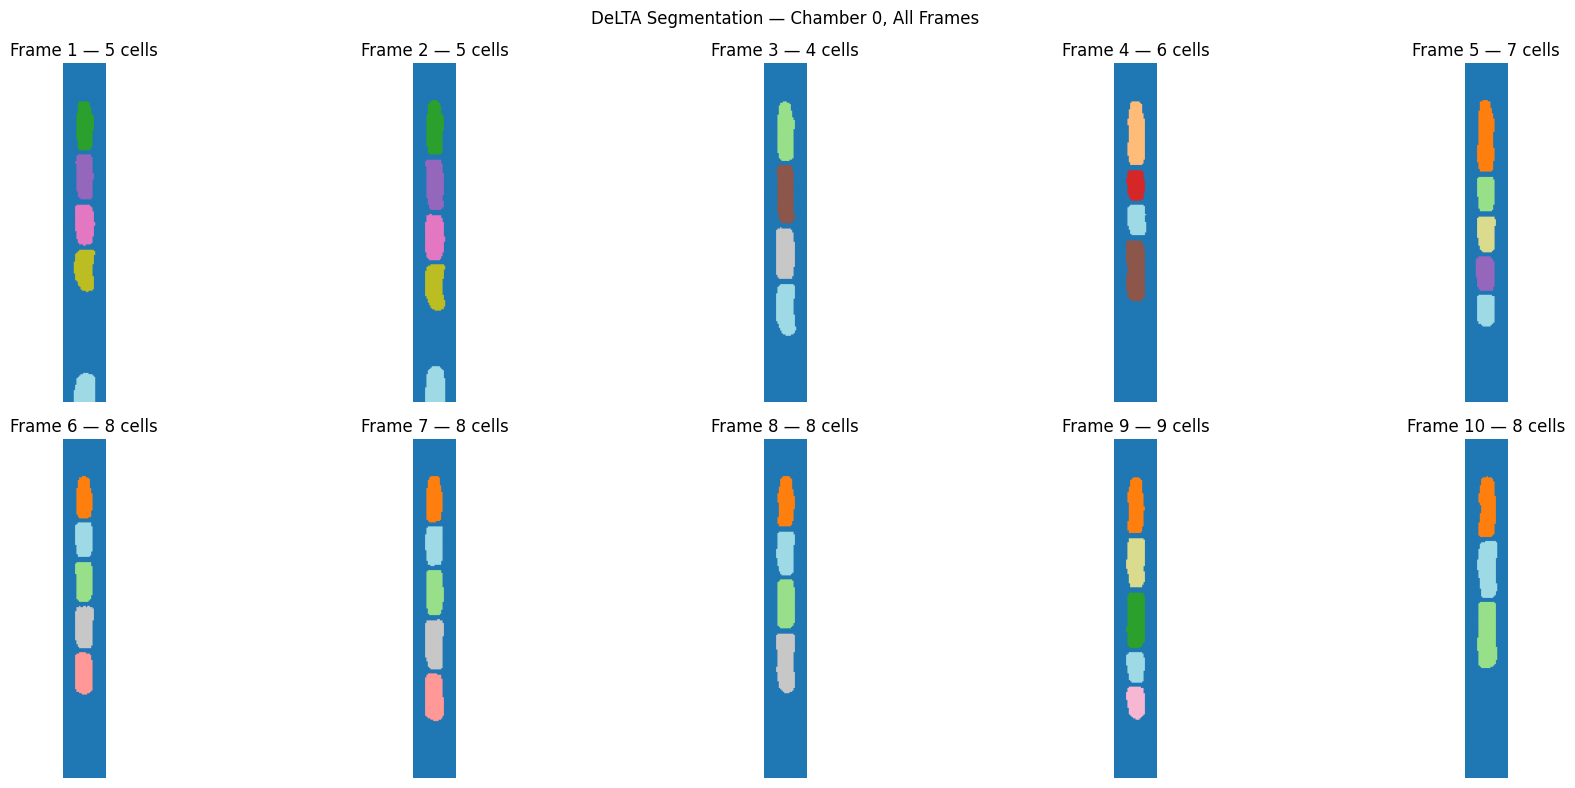


Segmentation summary:
  Frame 1: 5 cells
  Frame 2: 5 cells
  Frame 3: 4 cells
  Frame 4: 6 cells
  Frame 5: 7 cells
  Frame 6: 8 cells
  Frame 7: 8 cells
  Frame 8: 8 cells
  Frame 9: 9 cells
  Frame 10: 8 cells


In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os

# Verify correct TIF filename
tif_dir = "../data/raw/delta/tests/data/movie_mothermachine_tif"
tif_files = [f for f in os.listdir(tif_dir) if f.endswith('.tif')]
print("TIF files found:")
for f in sorted(tif_files)[:5]:
    print(f"  {f}")

# Load MAT
mat = scipy.io.loadmat(
    "../data/raw/delta/tests/data/movie_mothermachine_tif/expected_results/Position000001.mat",
    simplify_cells=False
)
res = mat['res']
chamber = res[0, 0]
labelsstack = chamber['labelsstack'][0, 0]
labelsstack_resized = chamber['labelsstack_resized'][0, 0]

print(f"\nlabelsstack shape: {labelsstack.shape}")
print(f"labelsstack_resized shape: {labelsstack_resized.shape}")
print(f"Cells in frame 0: {labelsstack[0].max()}")

# Load correct TIF
img_raw = tifffile.imread(
    "../data/raw/delta/tests/data/movie_mothermachine_tif/Position01Channel01Frames000001.tif"
)
print(f"Raw image shape: {img_raw.shape}")

# Visualize — use labelsstack_resized to match full image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title('Raw Phase Contrast (full frame)')
axes[1].imshow(labelsstack_resized[0], cmap='tab20')
axes[1].set_title(f"DeLTA Segmentation resized — {labelsstack_resized[0].max()} cells")
plt.tight_layout()
plt.savefig('../outputs/figures/week2_delta_segmentation.png', dpi=150)
plt.show()

# All 10 frames of chamber segmentation
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(labelsstack[i], cmap='tab20')
    ax.set_title(f'Frame {i+1} — {labelsstack[i].max()} cells')
    ax.axis('off')
plt.suptitle('DeLTA Segmentation — Chamber 0, All Frames')
plt.tight_layout()
plt.savefig('../outputs/figures/week2_delta_all_frames.png', dpi=150)
plt.show()

print("\nSegmentation summary:")
for i in range(labelsstack.shape[0]):
    print(f"  Frame {i+1}: {labelsstack[i].max()} cells")

In [3]:
import webbrowser

# Open these two URLs
urls = [
    "https://zenodo.org/communities/dunloplab",
    "https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1007673"
]

for url in urls:
    print(url)

https://zenodo.org/communities/dunloplab
https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1007673


In [4]:
# Run in your local notebook
import os

# Search for any README or data-related files in your delta clone
delta_path = "../data/raw/delta"
for root, dirs, files in os.walk(delta_path):
    # Skip .git folder
    if '.git' in root:
        continue
    for f in files:
        if any(keyword in f.lower() for keyword in ['readme', 'data', 'dataset', 'changelog']):
            full_path = os.path.join(root, f)
            print(f"\n{'='*50}")
            print(f"FILE: {full_path}")
            with open(full_path, 'r', encoding='utf-8', errors='ignore') as fh:
                content = fh.read()
                # Print lines mentioning data/zenodo/figshare/download
                for line in content.split('\n'):
                    if any(kw in line.lower() for kw in ['zenodo', 'figshare', 'data', 'download', 'dataset', 'training']):
                        print(line)


FILE: ../data/raw/delta\CHANGELOG.md
- The function `delta.data.make_weights` can create all of the weight maps
  for a training dataset.
- The function `load_training_dataset_seg` loads training datasets and allows
- Added the function `utils.training_callbacks` to simplify training.
- DeLTA assets (models, training sets, evaluation movies) are downloaded
- `CroppingBox` is now a `dataclass`, instead of a dictionary.
- Fixed training reproducibility bugs by using seeded random generators.
- The function `download_assets` was removed, because assets are now downloaded
- Fixed GPU memory crash when training by using cv2.imread in data module
- Updated assets module to new google drive download API
- Example scripts for data analysis and training & evaluation
- Systematic type hinting & standardization of data types
- Automated assets download of [training sets, latest models etc...](https://drive.google.com/drive/u/0/folders/1nTRVo0rPP9CR9F6WUunVXSXrLNMT_zCP)

FILE: ../data/raw/delta\R

In [5]:
# Check the assets.py file in the delta repo
with open('../data/raw/delta/delta/assets.py', 'r') as f:
    print(f.read())

"""
Asset downloads (model files, training sets, and demonstration movies).

We provide our trained models, training sets, and evaluation movies in `this
google drive folder
<https://drive.google.com/drive/folders/1nTRVo0rPP9CR9F6WUunVXSXrLNMT_zCP?usp=sharing>`_.
We refer to these data files as "assets".

You can of course download them manually, but shouldn't have to, because DeLTA
knows where to find them and downloads them automatically when needed, with the
`pooch library <https://www.fatiando.org/pooch/latest/>`_, which makes everything
completely transparent.

Cache location
--------------

Upon downloading the assets, DeLTA caches them in the default OS cache location
(see `the pooch documentation
<https://www.fatiando.org/pooch/latest/api/generated/pooch.os_cache.html>`_ for
details).  If you want to download them to a different location, you can
specify this path in the ``DELTA_ASSETS_CACHE`` environment variable.

For example, to set this variable permanently within your cond

In [7]:
# Install pooch
import subprocess
subprocess.run(['pip', 'install', 'pooch', '--break-system-packages'], 
               capture_output=True)

# Then restart kernel and run this standalone downloader
import pooch
import os
from pathlib import Path

os.environ['DELTA_ASSETS_CACHE'] = str(Path('../data/raw/delta_training').resolve())

BASE_URL = "https://drive.usercontent.google.com/download?confirm=t&id="

# Download mothermachine tracking training set (~few hundred MB)
registry = pooch.create(
    path=Path('../data/raw/delta_training') / "training_sets",
    base_url="",
    registry={
        "mothermachine_training_tracking.zip": 
            "sha256:75c8b7c764a9463d4ab1dcb432b464c17456ccd0e8b76b120b8eecf73364414d",
    },
    urls={
        "mothermachine_training_tracking.zip": 
            BASE_URL + "1XphzQzNKB97-JKPJ1QtGTI4_Wb7eY-pd",
    },
)

print("Downloading mothermachine tracking training set...")
path = registry.fetch(
    "mothermachine_training_tracking.zip",
    processor=pooch.Unzip(extract_dir="unzipped"),
    progressbar=True,
)
print(f"Downloaded to: {path}")

# List contents
base = Path('../data/raw/delta_training/training_sets/unzipped')
for root, dirs, files in os.walk(base):
    level = root.replace(str(base), '').count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:
        size = os.path.getsize(os.path.join(root, f)) / 1e6
        print(f"{indent}  {f}  ({size:.1f} MB)")
    if len(files) > 5:
        print(f"{indent}  ... and {len(files)-5} more files")

  0%|                                               | 0.00/246M [00:00<?, ?B/s]

Unzipping contents of 'E:\bacteria_iml\data\raw\delta_training\training_sets\mothermachine_training_tracking.zip' to 'E:\bacteria_iml\data\raw\delta_training\training_sets\unzipped'
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [8]:
import os
from pathlib import Path

base = Path('../data/raw/delta_training/training_sets/unzipped')

# Summary only — no recursive file listing
total_files = 0
total_size = 0
ext_map = {}
folder_summary = {}

for root, dirs, files in os.walk(base):
    folder = os.path.relpath(root, base)
    if files:
        folder_summary[folder] = len(files)
    for f in files:
        total_files += 1
        fp = os.path.join(root, f)
        size = os.path.getsize(fp)
        total_size += size
        ext = os.path.splitext(f)[1].lower()
        ext_map[ext] = ext_map.get(ext, 0) + 1

print(f"Total files: {total_files}")
print(f"Total size: {total_size/1e9:.2f} GB")
print(f"\nFile types:")
for ext, count in sorted(ext_map.items(), key=lambda x: -x[1]):
    print(f"  {ext:15s}: {count}")

print(f"\nTop-level folders and file counts:")
for folder, count in sorted(folder_summary.items()):
    depth = folder.count(os.sep)
    if depth <= 2:
        print(f"  {'  '*depth}{folder}  ({count} files)")

# Show 3 sample filenames from first folder found
print(f"\nSample filenames:")
for root, dirs, files in os.walk(base):
    if files:
        for f in files[:3]:
            print(f"  {f}")
        break

Total files: 85978
Total size: 0.22 GB

File types:
  .png           : 85978

Top-level folders and file counts:
      mothermachine_training_tracking\train\daughter  (4055 files)
      mothermachine_training_tracking\train\img  (4055 files)
      mothermachine_training_tracking\train\mother  (4055 files)
      mothermachine_training_tracking\train\previmg  (4055 files)
      mothermachine_training_tracking\train\seg  (4055 files)
      mothermachine_training_tracking\train\segall  (4055 files)
      mothermachine_training_tracking\train_multisets\daughter  (7706 files)
      mothermachine_training_tracking\train_multisets\img  (7706 files)
      mothermachine_training_tracking\train_multisets\mot_dau  (7706 files)
      mothermachine_training_tracking\train_multisets\mother  (7706 files)
      mothermachine_training_tracking\train_multisets\previmg  (7706 files)
      mothermachine_training_tracking\train_multisets\seg  (7706 files)
      mothermachine_training_tracking\train_multiset

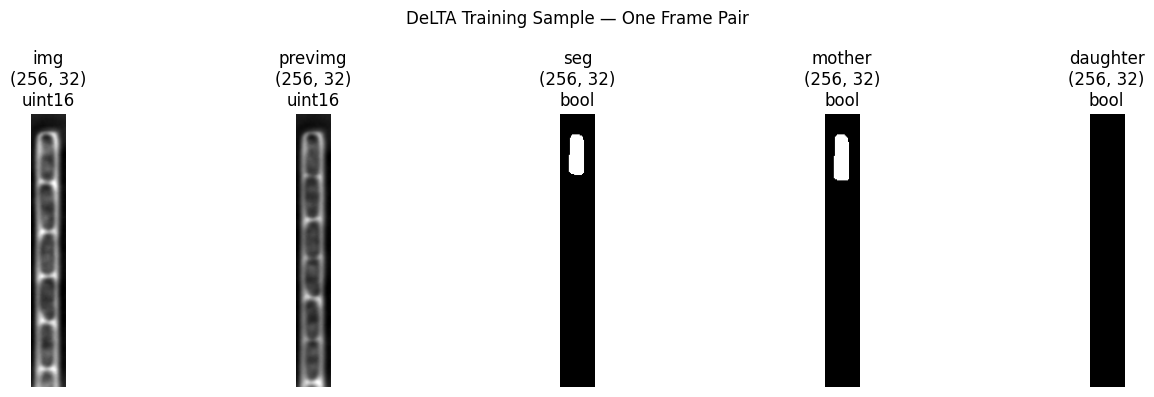

Total training samples: 7706
Sample names (first 10): ['sample_000001.png', 'sample_000002.png', 'sample_000003.png', 'sample_000004.png', 'sample_000005.png', 'sample_000006.png', 'sample_000007.png', 'sample_000008.png', 'sample_000009.png', 'sample_000010.png']
Sample names (last 5): ['sample_007702.png', 'sample_007703.png', 'sample_007704.png', 'sample_007705.png', 'sample_007706.png']


In [9]:
import tifffile
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from pathlib import Path

base = Path('../data/raw/delta_training/training_sets/unzipped/mothermachine_training_tracking/train_multisets')

# Load one sample across all channels
sample = 'sample_000001.png'
folders = ['img', 'previmg', 'seg', 'mother', 'daughter']

fig, axes = plt.subplots(1, len(folders), figsize=(15, 4))
for ax, folder in zip(axes, folders):
    path = base / folder / sample
    if path.exists():
        img = np.array(Image.open(path))
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{folder}\n{img.shape}\n{img.dtype}')
        ax.axis('off')

plt.suptitle('DeLTA Training Sample — One Frame Pair')
plt.tight_layout()
plt.savefig('../outputs/figures/week2_training_sample.png', dpi=150)
plt.show()

# Count unique positions/experiments
img_files = os.listdir(base / 'img')
print(f"Total training samples: {len(img_files)}")
print(f"Sample names (first 10): {sorted(img_files)[:10]}")
print(f"Sample names (last 5): {sorted(img_files)[-5:]}")

In [11]:
def subtract_background(img: np.ndarray, radius: int = 50) -> np.ndarray:
    """
    Rolling-ball background subtraction.
    For phase-contrast (dark cells on gray background), 
    we need to invert, subtract, then invert back.
    """
    from skimage import restoration
    
    # Shift to positive range before rolling ball
    img_shifted = img - img.min()
    background = restoration.rolling_ball(img_shifted, radius=radius)
    corrected = img_shifted - background
    
    # Re-center to zero mean
    corrected = corrected - corrected.mean()
    return corrected